In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from google.colab import drive

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')


DATA_PATH = "/content/drive/MyDrive/Colab/datasets/free-spoken-digit-dataset/recordings"


file_names = sorted([f for f in os.listdir(DATA_PATH) if f.endswith('.wav')])
labels = [int(f.split('_')[0]) for f in file_names]

print(f"Número de archivos: {len(file_names)}")
print(f"Ejemplo: {file_names[:3]}")
print(f"Distribución de clases: {np.bincount(labels)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Número de archivos: 3000
Ejemplo: ['0_george_0.wav', '0_george_1.wav', '0_george_10.wav']
Distribución de clases: [300 300 300 300 300 300 300 300 300 300]


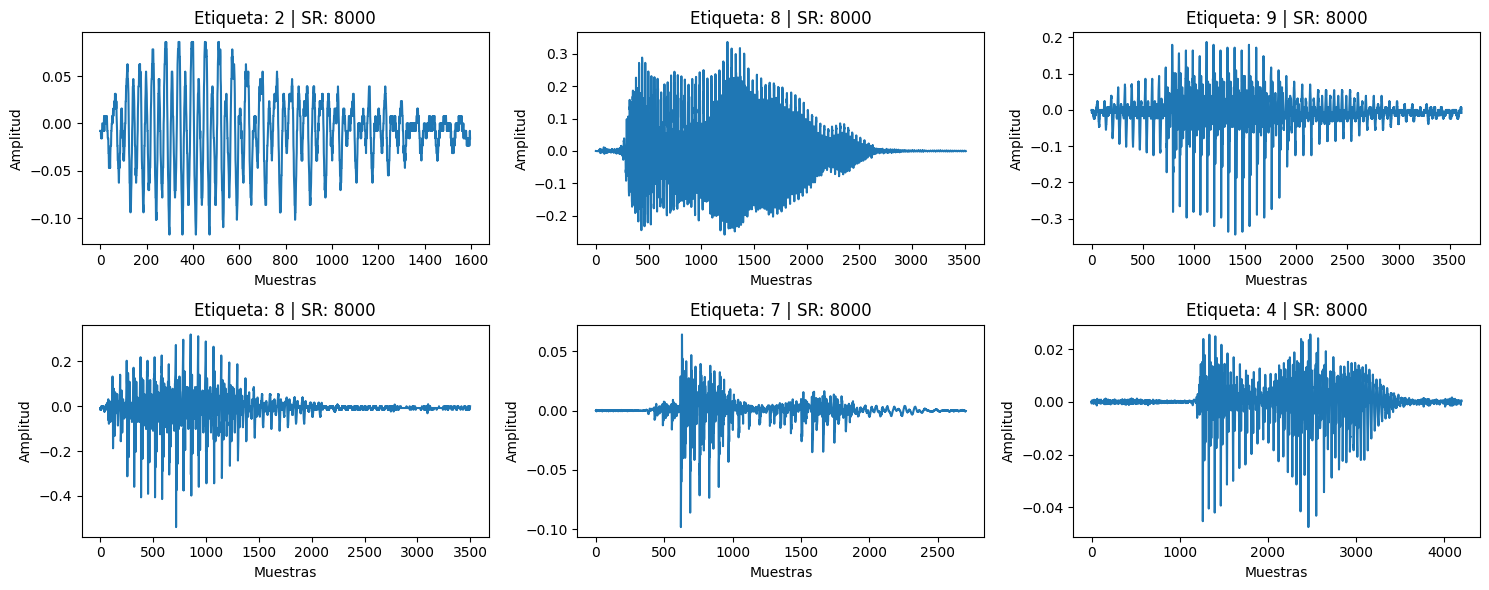

Duración media: 0.44s | Máx: 2.28s | Mín: 0.14s


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for ax in axes.flatten():
    idx = np.random.randint(len(file_names))
    waveform, sr = torchaudio.load(os.path.join(DATA_PATH, file_names[idx]))
    ax.plot(waveform.t().numpy())
    ax.set_title(f"Etiqueta: {labels[idx]} | SR: {sr}")
    ax.set_xlabel("Muestras"); ax.set_ylabel("Amplitud")
plt.tight_layout()
plt.show()


durations = []
for f in file_names:
    waveform, sr = torchaudio.load(os.path.join(DATA_PATH, f))
    durations.append(waveform.shape[1] / sr)
print(f"Duración media: {np.mean(durations):.2f}s | Máx: {np.max(durations):.2f}s | Mín: {np.min(durations):.2f}s")




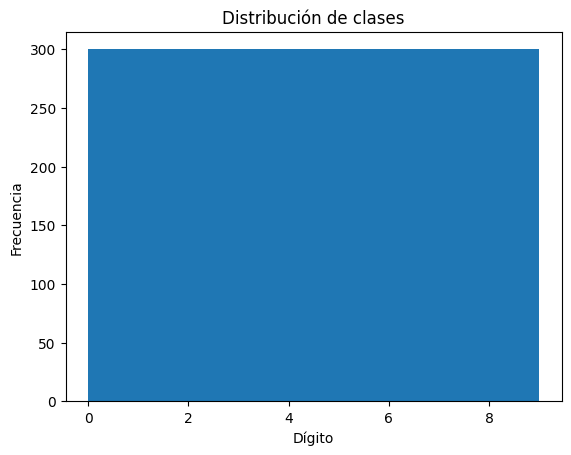

In [26]:
plt.hist(labels, bins=10)
plt.title("Distribución de clases"); plt.xlabel("Dígito"); plt.ylabel("Frecuencia")
plt.show()

In [5]:

train_files, val_files, train_labels, val_labels = train_test_split(
    file_names, labels, test_size=0.2, random_state=42, stratify=labels
)

X_subset_files, y_subset = train_files[:1000], train_labels[:1000]
X_val_files, y_val = val_files, val_labels

print("Train completo:", len(train_files))
print("Subconjunto (rápido):", len(X_subset_files))
print("Validación:", len(X_val_files))

Train completo: 2400
Subconjunto (rápido): 1000
Validación: 600


In [6]:
class AudioAugment:
    """Data augmentation en el dominio temporal."""
    def __init__(self, p_noise=0.5, p_shift=0.5, p_gain=0.5):
        self.p_noise = p_noise
        self.p_shift = p_shift
        self.p_gain = p_gain

    def __call__(self, waveform):
        if np.random.rand() < self.p_noise:
            noise = torch.randn_like(waveform) * 0.005
            waveform = waveform + noise
        if np.random.rand() < self.p_shift:
            shift = np.random.randint(-800, 800)
            waveform = torch.roll(waveform, shift, dims=1)
        if np.random.rand() < self.p_gain:
            gain = np.random.uniform(0.8, 1.2)
            waveform = waveform * gain
        return waveform


class AudioDataset(Dataset):

    def __init__(self, file_names, labels, data_path, trans=None,
                 mean=None, std=None):
        self.file_names = file_names
        self.labels = labels
        self.data_path = data_path
        self.trans = trans

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=8000, n_fft=256, hop_length=64, n_mels=64
        )
        self.amp_to_db = torchaudio.transforms.AmplitudeToDB(top_db=80)

        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        filepath = os.path.join(self.data_path, self.file_names[idx])
        waveform, _ = torchaudio.load(filepath)


        waveform = waveform / (waveform.abs().max() + 1e-8)


        target_len = 8000
        if waveform.shape[1] < target_len:
            waveform = F.pad(waveform, (0, target_len - waveform.shape[1]))
        else:
            waveform = waveform[:, :target_len]


        if self.trans is not None:
            waveform = self.trans(waveform)


        mel_spec = self.mel_transform(waveform)
        mel_spec = self.amp_to_db(mel_spec)


        if self.mean is not None and self.std is not None:
            mel_spec = (mel_spec - self.mean) / (self.std + 1e-6)

        label = torch.tensor(self.labels[idx]).long()
        return mel_spec, label

In [7]:

def compute_stats(file_names, data_path):
    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=8000, n_fft=256, hop_length=64, n_mels=64
    )
    amp_to_db = torchaudio.transforms.AmplitudeToDB(top_db=80)

    specs = []
    for f in file_names:
        waveform, _ = torchaudio.load(os.path.join(data_path, f))
        waveform = waveform / (waveform.abs().max() + 1e-8)
        target_len = 8000
        if waveform.shape[1] < target_len:
            waveform = F.pad(waveform, (0, target_len - waveform.shape[1]))
        else:
            waveform = waveform[:, :target_len]
        mel = amp_to_db(mel_transform(waveform))
        specs.append(mel)

    specs = torch.stack(specs)
    return specs.mean().item(), specs.std().item()

MEAN, STD = compute_stats(train_files, DATA_PATH)
print(f"mean={MEAN:.4f}, std={STD:.4f}")

mean=-35.3884, std=23.2045


In [8]:

class AudioCNN(nn.Module):
    def __init__(self, n_classes=10, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, n_classes)

        self.dropout = nn.Dropout(dropout)
        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(64)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [9]:

def fit(model, dataloader, optimizer, scheduler=None, epochs=10, log_each=1,
        early_stopping=0, verbose=1, device='cuda'):
    criterion = nn.CrossEntropyLoss()
    l, acc, lr = [], [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs + 1):
        _l, _acc = [], []
        for param_group in optimizer.param_groups:
            lr.append(param_group['lr'])


        model.train()
        for x_b, y_b in dataloader['train']:
            x_b, y_b = x_b.to(device), y_b.to(device)
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_pred_class = torch.argmax(y_pred, axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(),
                                       y_pred_class.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))


        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                x_b, y_b = x_b.to(device), y_b.to(device)
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_pred_class = torch.argmax(y_pred, axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(),
                                           y_pred_class.cpu().detach().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))


        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            if verbose == 2:
                print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1

        if scheduler:
            scheduler.step()


        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs")
            break

        if not e % log_each and verbose:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} "
                  f"val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f} lr {lr[-1]:.5f}")

    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l) + 1)), 'loss': l, 'acc': acc,
            'val_loss': val_l, 'val_acc': val_acc, 'lr': lr}

In [10]:

ds_check = AudioDataset(X_subset_files, y_subset, DATA_PATH, mean=MEAN, std=STD)
x, y = ds_check[0]
print("Muestra individual:", x.shape)

dl_check = DataLoader(ds_check, batch_size=16)
xb, yb = next(iter(dl_check))
print("Batch:", xb.shape, yb.shape)

model_test = AudioCNN().to(device)
out = model_test(xb.to(device))
print("Salida:", out.shape)


ds_one = AudioDataset(X_subset_files[:1], y_subset[:1], DATA_PATH, mean=MEAN, std=STD)
dl_one = DataLoader(ds_one, batch_size=1)

model = AudioCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1, 51):
    for x_b, y_b in dl_one:
        x_b, y_b = x_b.to(device), y_b.to(device)
        y_pred = model(x_b)
        loss = criterion(y_pred, y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch} loss {loss.item():.5f} "
              f"y {y_b.item()} y_pred {torch.argmax(y_pred).item()}")

ds_batch = AudioDataset(X_subset_files[:64], y_subset[:64], DATA_PATH, mean=MEAN, std=STD)
dl_batch = DataLoader(ds_batch, batch_size=64, shuffle=True)

model = AudioCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1, 201):
    for x_b, y_b in dl_batch:
        x_b, y_b = x_b.to(device), y_b.to(device)
        y_pred = model(x_b)
        loss = criterion(y_pred, y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 20 == 0:
        acc = (y_b == torch.argmax(y_pred, axis=1)).sum().item()
        print(f"Epoch {epoch}/200 loss {loss.item():.5f} acc {acc}/{y_b.shape[0]}")

Muestra individual: torch.Size([1, 64, 126])
Batch: torch.Size([16, 1, 64, 126]) torch.Size([16])
Salida: torch.Size([16, 10])
Epoch 10 loss 0.00000 y 1 y_pred 1
Epoch 20 loss 0.00000 y 1 y_pred 1
Epoch 30 loss 0.00000 y 1 y_pred 1
Epoch 40 loss 0.00000 y 1 y_pred 1
Epoch 50 loss 0.00000 y 1 y_pred 1
Epoch 20/200 loss 2.03345 acc 12/64
Epoch 40/200 loss 1.28964 acc 30/64
Epoch 60/200 loss 0.98451 acc 42/64
Epoch 80/200 loss 0.71778 acc 48/64
Epoch 100/200 loss 0.68021 acc 49/64
Epoch 120/200 loss 0.60322 acc 50/64
Epoch 140/200 loss 0.71286 acc 44/64
Epoch 160/200 loss 0.62626 acc 48/64
Epoch 180/200 loss 0.56194 acc 51/64
Epoch 200/200 loss 0.53911 acc 50/64


Train: 1000 | Val: 600
Probando lr 0.0005
Probando lr 0.0002
Probando lr 0.0001


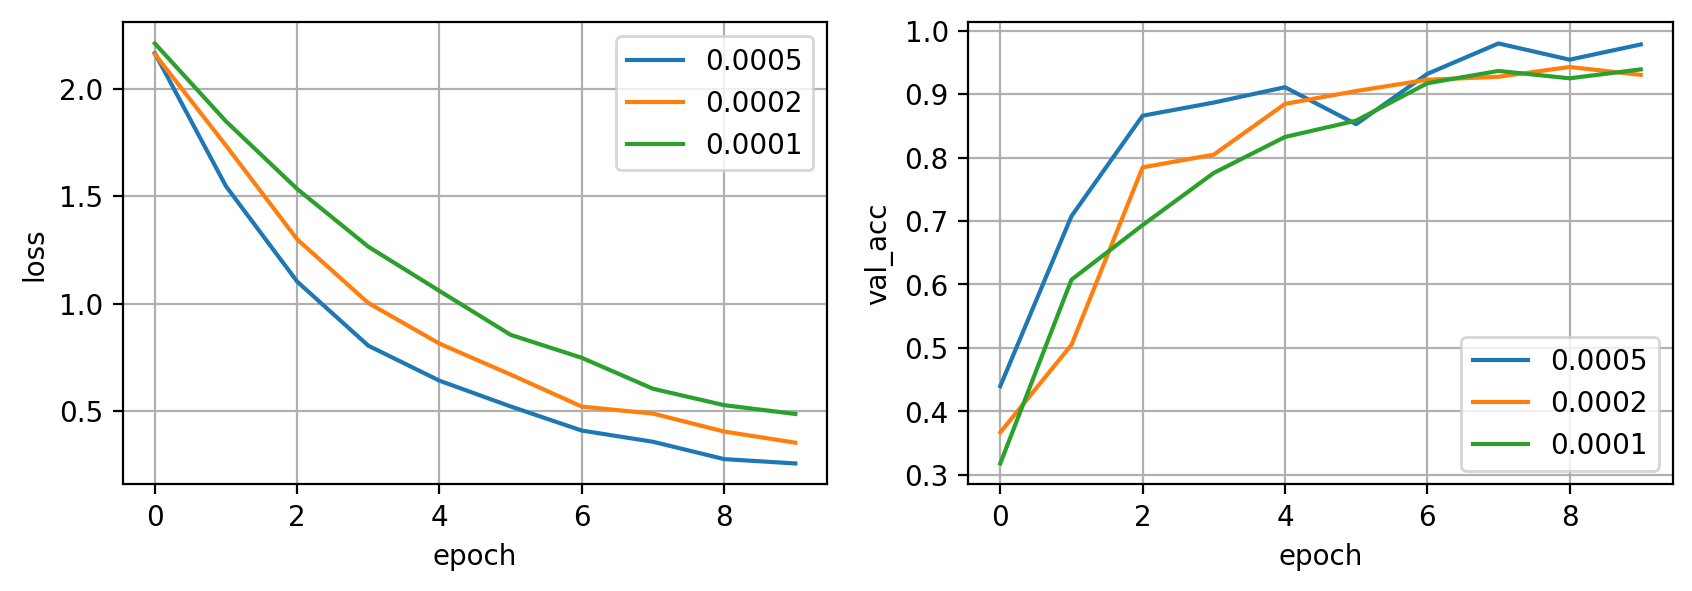

In [11]:
dataset = {
    'train': AudioDataset(X_subset_files, y_subset, DATA_PATH, mean=MEAN, std=STD),
    'val':   AudioDataset(X_val_files,    y_val,    DATA_PATH, mean=MEAN, std=STD),
}

dataloader = {
    'train': DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val':   DataLoader(dataset['val'],   batch_size=128, shuffle=False),
}

print("Train:", len(dataset['train']), "| Val:", len(dataset['val']))

lrs = [0.0005, 0.0002, 0.0001]
hists = []
for lr in lrs:
    print(f"Probando lr {lr}")
    model = AudioCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = fit(model, dataloader, optimizer, epochs=10, verbose=0, device=device)
    hists.append(hist)

fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
for i in range(len(lrs)):
    ax.plot(hists[i]['loss'], label=lrs[i])
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax = plt.subplot(122)
for i in range(len(lrs)):
    ax.plot(hists[i]['val_acc'], label=lrs[i])
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('val_acc')
plt.show()

Probando bs 16
Probando bs 32
Probando bs 64


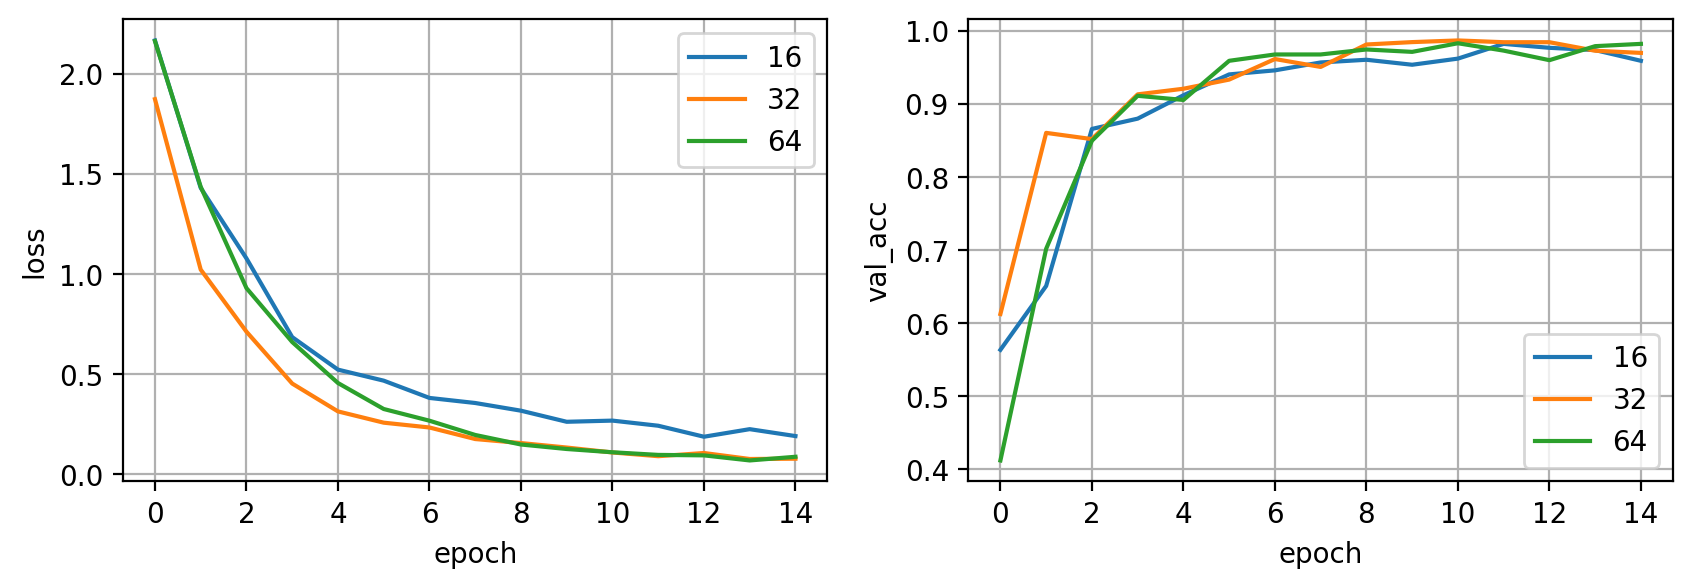

In [12]:
bss = [16, 32, 64]
hists = []

for bs in bss:
    print(f"Probando bs {bs}")
    dataloader = {
        'train': DataLoader(dataset['train'], batch_size=bs, shuffle=True),
        'val':   DataLoader(dataset['val'],   batch_size=128, shuffle=False),
    }
    model = AudioCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    hist = fit(model, dataloader, optimizer, epochs=15, verbose=0, device=device)
    hists.append(hist)

fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
for i in range(len(bss)):
    ax.plot(hists[i]['loss'], label=bss[i])
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax = plt.subplot(122)
for i in range(len(bss)):
    ax.plot(hists[i]['val_acc'], label=bss[i])
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('val_acc')
plt.show()

Probando lr 0.01
Probando lr 0.005
Probando lr 0.001
Probando lr 0.0003


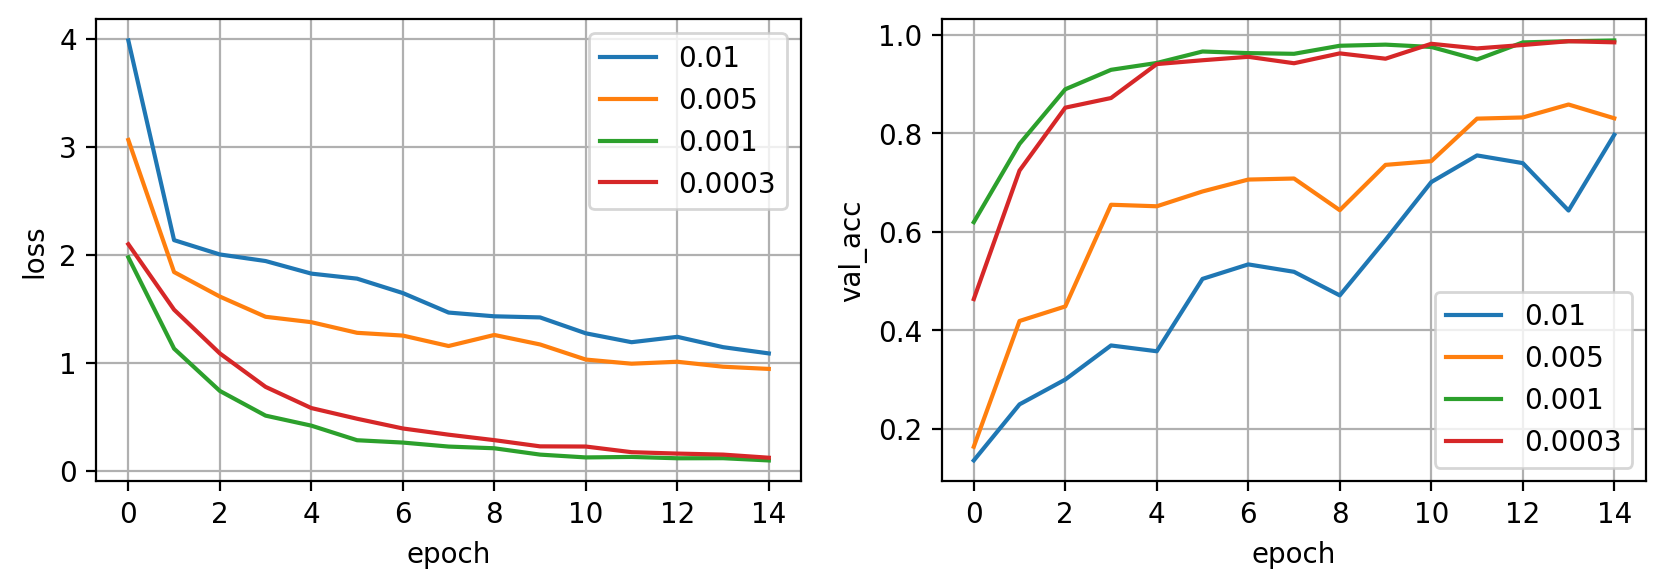

In [13]:
lrs = [0.01, 0.005, 0.001, 0.0003]
hists = []

dataloader = {
    'train': DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val':   DataLoader(dataset['val'],   batch_size=128, shuffle=False),
}

for lr in lrs:
    print(f"Probando lr {lr}")
    model = AudioCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = fit(model, dataloader, optimizer, epochs=15, verbose=0, device=device)
    hists.append(hist)

fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
for i in range(len(lrs)):
    ax.plot(hists[i]['loss'], label=lrs[i])
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax = plt.subplot(122)
for i in range(len(lrs)):
    ax.plot(hists[i]['val_acc'], label=lrs[i])
ax.legend(); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('val_acc')
plt.show()

Mejor modelo guardado con acc 0.38594 en epoch 1
Epoch 1/100 loss 2.22502 acc 0.21875 val_loss 1.83708 val_acc 0.38594 lr 0.00100
Mejor modelo guardado con acc 0.69503 en epoch 2
Epoch 2/100 loss 1.65397 acc 0.39648 val_loss 1.18098 val_acc 0.69503 lr 0.00100
Mejor modelo guardado con acc 0.82159 en epoch 3
Epoch 3/100 loss 1.22387 acc 0.57812 val_loss 0.68482 val_acc 0.82159 lr 0.00100
Mejor modelo guardado con acc 0.90611 en epoch 4
Epoch 4/100 loss 0.90872 acc 0.67578 val_loss 0.49105 val_acc 0.90611 lr 0.00100
Mejor modelo guardado con acc 0.94503 en epoch 5
Epoch 5/100 loss 0.73628 acc 0.75293 val_loss 0.35155 val_acc 0.94503 lr 0.00100
Epoch 6/100 loss 0.61613 acc 0.78223 val_loss 0.32894 val_acc 0.92812 lr 0.00100
Mejor modelo guardado con acc 0.95966 en epoch 7
Epoch 7/100 loss 0.50450 acc 0.84082 val_loss 0.22791 val_acc 0.95966 lr 0.00100
Mejor modelo guardado con acc 0.96051 en epoch 8
Epoch 8/100 loss 0.42849 acc 0.84961 val_loss 0.16546 val_acc 0.96051 lr 0.00100
Mejor mod

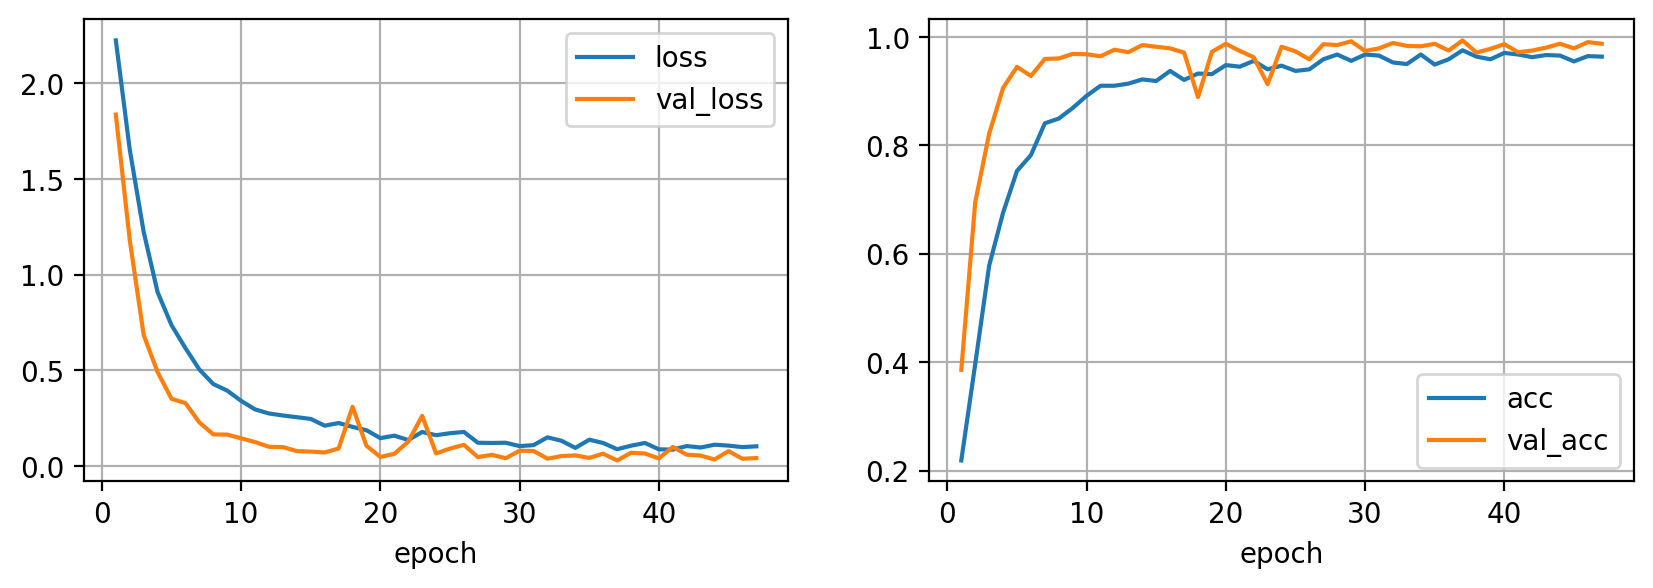

In [14]:
trans = AudioAugment(p_noise=0.5, p_shift=0.5, p_gain=0.5)

dataset_aug = {
    'train': AudioDataset(X_subset_files, y_subset, DATA_PATH, trans=trans,
                          mean=MEAN, std=STD),
    'val':   AudioDataset(X_val_files,    y_val,    DATA_PATH,
                          mean=MEAN, std=STD),
}

dataloader_aug = {
    'train': DataLoader(dataset_aug['train'], batch_size=32, shuffle=True),
    'val':   DataLoader(dataset_aug['val'],   batch_size=128, shuffle=False),
}

model = AudioCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
hist = fit(model, dataloader_aug, optimizer, epochs=100,
           early_stopping=10, verbose=2, device=device)

fig = plt.figure(dpi=200, figsize=(10, 3))
ax = plt.subplot(121)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

Test 1/6 → lr 0.001 | bs 32
Test 2/6 → lr 0.0001 | bs 128
Test 3/6 → lr 0.01 | bs 128
Test 4/6 → lr 0.005 | bs 128
Test 5/6 → lr 0.005 | bs 16
Test 6/6 → lr 0.01 | bs 128


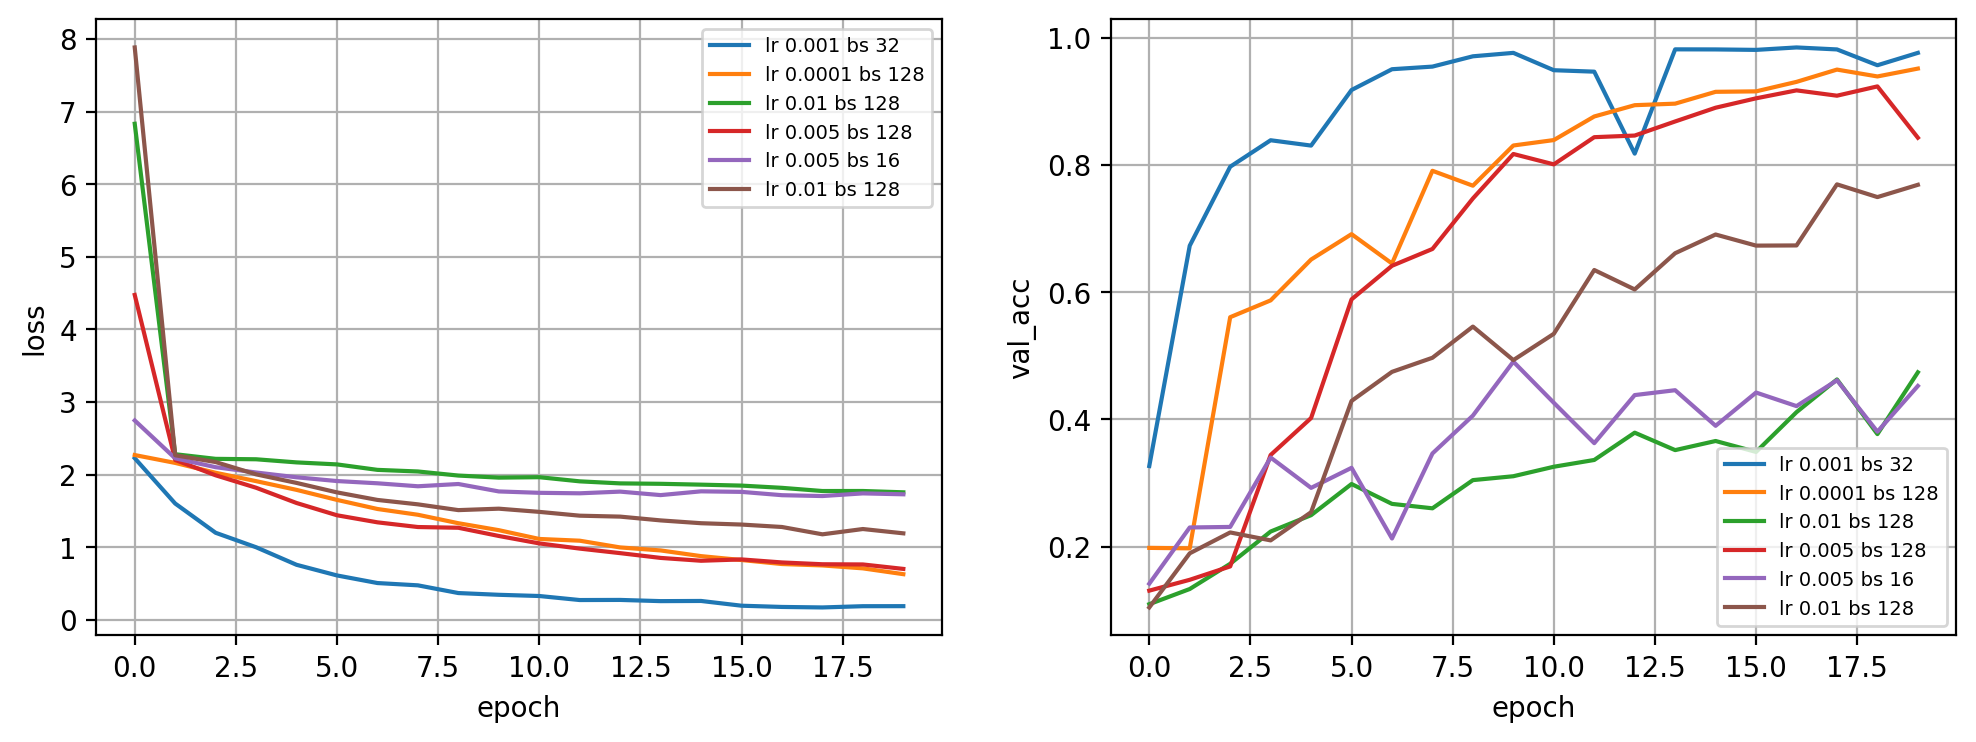

Mejor combinación: lr=0.001, bs=32, val_acc=0.9845


In [15]:
bss = [16, 32, 64, 128]
lrs = [0.01, 0.005, 0.001, 0.0003, 0.0001]
n = 6
hists = []

for i in range(n):
    lr = random.choice(lrs)
    bs = random.choice(bss)
    print(f"Test {i+1}/{n} → lr {lr} | bs {bs}")

    dataloader = {
        'train': DataLoader(dataset_aug['train'], batch_size=bs, shuffle=True),
        'val':   DataLoader(dataset_aug['val'],   batch_size=128, shuffle=False),
    }
    model = AudioCNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = fit(model, dataloader, optimizer, epochs=20, verbose=0, device=device)
    hists.append({'hist': hist, 'lr': lr, 'bs': bs,
                  'best_val_acc': max(hist['val_acc'])})

fig = plt.figure(dpi=200, figsize=(12, 4))
ax = plt.subplot(121)
for h in hists:
    ax.plot(h['hist']['loss'], label=f"lr {h['lr']} bs {h['bs']}")
ax.legend(fontsize=7); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('loss')
ax = plt.subplot(122)
for h in hists:
    ax.plot(h['hist']['val_acc'], label=f"lr {h['lr']} bs {h['bs']}")
ax.legend(fontsize=7); ax.grid(True); ax.set_xlabel('epoch'); ax.set_ylabel('val_acc')
plt.show()

best = max(hists, key=lambda x: x['best_val_acc'])
print(f"Mejor combinación: lr={best['lr']}, bs={best['bs']}, val_acc={best['best_val_acc']:.4f}")

Mejor modelo guardado con acc 0.72528 en epoch 1
Epoch 1/100 loss 1.70509 acc 0.38458 val_loss 0.88733 val_acc 0.72528 lr 0.00100
Mejor modelo guardado con acc 0.90298 en epoch 2
Epoch 2/100 loss 0.86917 acc 0.69333 val_loss 0.38980 val_acc 0.90298 lr 0.00100
Mejor modelo guardado con acc 0.91463 en epoch 3
Epoch 3/100 loss 0.55092 acc 0.80667 val_loss 0.33526 val_acc 0.91463 lr 0.00100
Mejor modelo guardado con acc 0.96733 en epoch 4
Epoch 4/100 loss 0.40030 acc 0.86625 val_loss 0.14893 val_acc 0.96733 lr 0.00100
Mejor modelo guardado con acc 0.98139 en epoch 5
Epoch 5/100 loss 0.32111 acc 0.89125 val_loss 0.08284 val_acc 0.98139 lr 0.00100
Mejor modelo guardado con acc 0.98224 en epoch 6
Epoch 6/100 loss 0.25945 acc 0.91500 val_loss 0.05969 val_acc 0.98224 lr 0.00100
Epoch 7/100 loss 0.23836 acc 0.92625 val_loss 0.13116 val_acc 0.95653 lr 0.00100
Mejor modelo guardado con acc 0.98366 en epoch 8
Epoch 8/100 loss 0.21845 acc 0.93000 val_loss 0.06621 val_acc 0.98366 lr 0.00100
Mejor mod

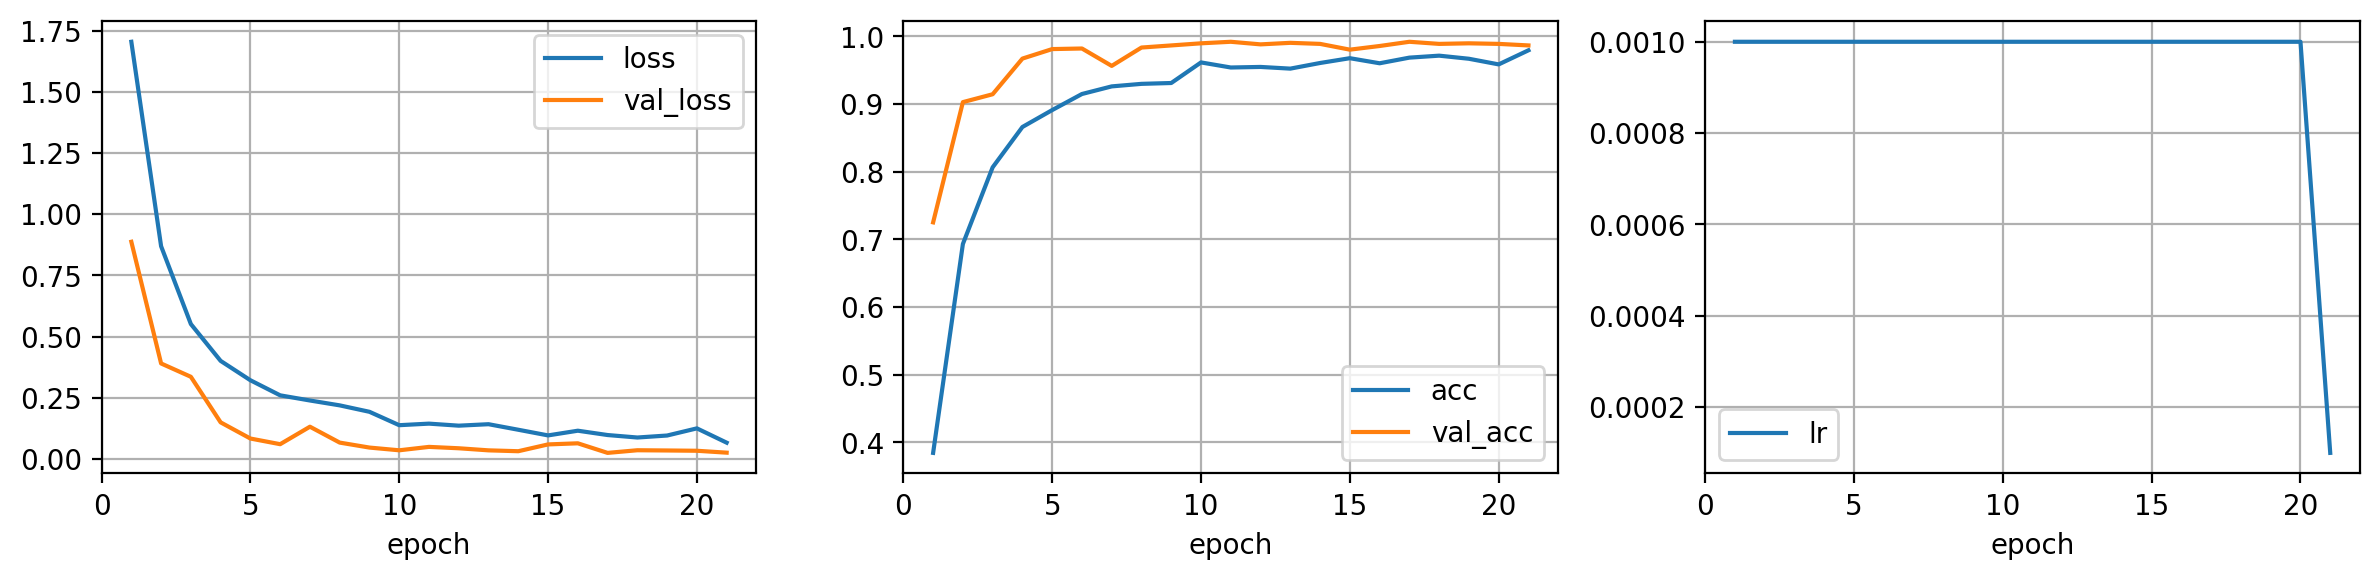

In [16]:
trans = AudioAugment()

dataset_full = {
    'train': AudioDataset(train_files, train_labels, DATA_PATH, trans=trans,
                          mean=MEAN, std=STD),
    'val':   AudioDataset(val_files,   val_labels,   DATA_PATH,
                          mean=MEAN, std=STD),
}

dataloader_full = {
    'train': DataLoader(dataset_full['train'], batch_size=32, shuffle=True),
    'val':   DataLoader(dataset_full['val'],   batch_size=128, shuffle=False),
}

model = AudioCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

hist = fit(model, dataloader_full, optimizer, scheduler=scheduler,
           epochs=100, early_stopping=10, verbose=2, device=device)

fig = plt.figure(dpi=200, figsize=(12, 3))
ax = plt.subplot(131)
pd.DataFrame(hist).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(132)
pd.DataFrame(hist).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
ax = plt.subplot(133)
pd.DataFrame(hist).plot(x='epoch', y=['lr'], grid=True, ax=ax)
plt.tight_layout()
plt.show()

In [27]:
print(type(model).__name__)                       # debe ser AudioCNN
xb, yb = next(iter(dataloader['test']))
with torch.no_grad():
    out = model(xb.to(device))
print("Salida del modelo:", out.shape)             # (B, 10)
print("Etiquetas del dataloader:", yb.shape)       # (B,)

AudioCNN
Salida del modelo: torch.Size([128, 10])
Etiquetas del dataloader: torch.Size([128])


In [28]:


@torch.no_grad()
def predict_proba_class5(model, dataloader, device='cuda', class_idx=5):

    model.eval()
    probs5, labels = [], []
    for x_b, y_b in dataloader:
        x_b = x_b.to(device)
        logits = model(x_b)
        probs = F.softmax(logits, dim=1)
        probs5.append(probs[:, class_idx].cpu().numpy())
        labels.append(y_b.numpy())
    return np.concatenate(probs5), np.concatenate(labels)


def evaluate_binary_from_multiclass(model, dataloader, device='cuda',
                                    class_idx=5, threshold=0.5):

    prob5, y_mc = predict_proba_class5(model, dataloader, device, class_idx)

    y_pred = (prob5 > threshold).astype(np.int64)
    y_true_5 = (y_mc == class_idx).astype(np.int64)
    return y_pred, y_true_5, prob5, y_mc

In [29]:
y_pred, y_test_5, y_prob, y_mc = evaluate_binary_from_multiclass(
    model, dataloader['test'], device=device, class_idx=5
)

print("Forma y_pred:    ", y_pred.shape)
print("Forma y_test_5:  ", y_test_5.shape)
print("Forma y_prob:    ", y_prob.shape)

Forma y_pred:     (450,)
Forma y_test_5:   (450,)
Forma y_prob:     (450,)


In [30]:
def accuracy(y_pred, y):
    return np.sum(y_pred == y) / len(y)

accuracy(y_pred, y_test_5)

np.float64(0.9044444444444445)

In [32]:
1 - y_test_5.mean()

np.float64(1.0)

In [33]:
TP = np.sum((y_pred == 1) & (y_test_5 == 1))
TN = np.sum((y_pred == 0) & (y_test_5 == 0))
FP = np.sum((y_pred == 1) & (y_test_5 == 0))
FN = np.sum((y_pred == 0) & (y_test_5 == 1))

CM = [[TN, FP],
      [FN, TP]]
CM

[[np.int64(407), np.int64(43)], [np.int64(0), np.int64(0)]]

In [34]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test_5, y_pred)

array([[407,  43],
       [  0,   0]])

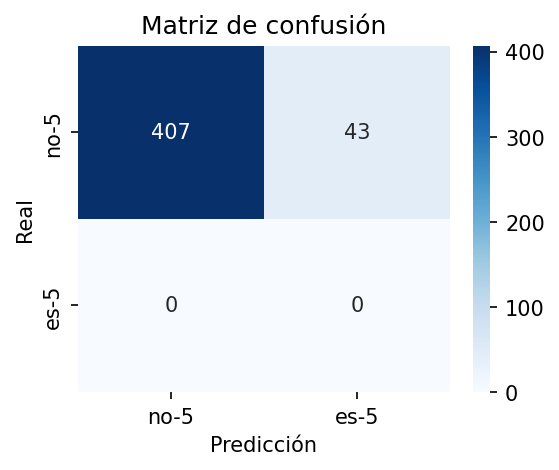

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3), dpi=150)
sns.heatmap(confusion_matrix(y_test_5, y_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['no-5', 'es-5'],
            yticklabels=['no-5', 'es-5'])
plt.xlabel('Predicción'); plt.ylabel('Real')
plt.title('Matriz de confusión')
plt.show()